In [136]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.svm import SVR
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, precision_recall_fscore_support, accuracy_score
from sklearn import preprocessing
from sklearn.model_selection import StratifiedShuffleSplit
from datetime import datetime
import geopandas as gpd
import numpy as np
import glob

# Loading multiple CSVs to merge the samples - if it is the case:

In [137]:

# Specify the directory where the CSV files are located
directory = r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1'

# Use the glob module to retrieve a list of file paths that match the pattern '*.csv' in the specified directory and its subdirectories
#file_list = glob.glob(directory + '/**/*.csv', recursive=True)

# Create an empty dataframe to store the concatenated data
#df = pd.DataFrame()

# Loop through the file list and read each CSV file using pd.read_csv(), and concatenate it to the dataframe
"""
for file in file_list:
    df_temp = pd.read_csv(file)
    # Extract the date from the filename (assuming the filename has a date string in it)
    date_str = file.split('LARGO1')[1].split("\\")[1]
    if date_str == '11-17-2021' or date_str == '10-07-2021' or date_str == '10-26-2021':
        continue
    date_obj = datetime.strptime(date_str, '%m-%d-%Y')
    desired_year = 2021
    correct_date_obj = date_obj.replace(year=desired_year)

    formatted_date_str = correct_date_obj.strftime('%m/%d/%Y')
    date = pd.to_datetime(formatted_date_str).date()
    
    # Add a new column for the date
    df_temp['date'] = date
    print('Dataset for date', date, 'added.')

    df = pd.concat([df, df_temp], ignore_index=True)
"""


'\nfor file in file_list:\n    df_temp = pd.read_csv(file)\n    # Extract the date from the filename (assuming the filename has a date string in it)\n    date_str = file.split(\'LARGO1\')[1].split("\\")[1]\n    if date_str == \'11-17-2021\' or date_str == \'10-07-2021\' or date_str == \'10-26-2021\':\n        continue\n    date_obj = datetime.strptime(date_str, \'%m-%d-%Y\')\n    desired_year = 2021\n    correct_date_obj = date_obj.replace(year=desired_year)\n\n    formatted_date_str = correct_date_obj.strftime(\'%m/%d/%Y\')\n    date = pd.to_datetime(formatted_date_str).date()\n    \n    # Add a new column for the date\n    df_temp[\'date\'] = date\n    print(\'Dataset for date\', date, \'added.\')\n\n    df = pd.concat([df, df_temp], ignore_index=True)\n'

# Loading training and target dataframes

In [138]:
df = []
df_target = []

def dataset_load():
    df = []
    df1 = pd.read_csv(r'./dataset/LARGO1/08-30/VALUES/values.csv')
    df1_2 = pd.read_csv(r'./dataset/LARGO2/08-30/VALUES/values.csv')
    df2 = pd.read_csv(r'./dataset/LARGO1/09-24/VALUES/values.csv')
    df2_2 = pd.read_csv(r'./dataset/LARGO2/09-24/VALUES/values.csv')
    df3 = pd.read_csv(r'./dataset/LARGO1/10-05/VALUES/values.csv')
    df3_2 = pd.read_csv(r'./dataset/LARGO2/10-05/VALUES/values.csv')
    df4 = pd.read_csv(r'./dataset/LARGO1/10-07/VALUES/values.csv')
    df4_2 = pd.read_csv(r'./dataset/LARGO2/10-07/VALUES/values.csv')
    df5 = pd.read_csv(r'./dataset/LARGO1/10-26/VALUES/values.csv')
    df5_2 = pd.read_csv(r'./dataset/LARGO2/10-26/VALUES/values.csv')
    df1_synthetic = pd.read_csv(r'./dataset/LARGO1/08-30-synthetic/VALUES/values.csv')
    # Multiplicate the columns of the synthetic dataset by 1.3, excluding the HEALTH_STA column:
    df1_synthetic = df1_synthetic[df1_synthetic['HEALTH_STA'] == 'UNHEALTHY']
    df1_synthetic.iloc[:, 1:-1] = df1_synthetic.iloc[:, 1:-1].apply(lambda x: x/1.7)
    df2_synthetic = pd.read_csv(r'./dataset/LARGO1/09-24-synthetic/VALUES/values.csv')
    df2_synthetic = df2_synthetic[df2_synthetic['HEALTH_STA'] == 'UNHEALTHY']
    df2_synthetic.iloc[:, 1:-1] = df2_synthetic.iloc[:, 1:-1].apply(lambda x: x/1.7)
    df3_synthetic = pd.read_csv(r'./dataset/LARGO1/10-05-synthetic/VALUES/values.csv')
    df3_synthetic = df3_synthetic[df3_synthetic['HEALTH_STA'] == 'UNHEALTHY']
    df3_synthetic.iloc[:, 1:-1] = df3_synthetic.iloc[:, 1:-1].apply(lambda x: x/1.7)
    df4_synthetic = pd.read_csv(r'./dataset/LARGO1/10-07-synthetic/VALUES/values.csv')
    df4_synthetic.iloc[:, 1:-1] = df4_synthetic.iloc[:, 1:-1].apply(lambda x: x*1.7)
    df5_synthetic = pd.read_csv(r'./dataset/LARGO1/10-26-synthetic/VALUES/values.csv')
    df5_synthetic = df5_synthetic[df5_synthetic['HEALTH_STA'] == 'UNHEALTHY']
    df5_synthetic.iloc[:, 1:-1] = df5_synthetic.iloc[:, 1:-1].apply(lambda x: x/1.7)   
    # Select only rows with HEALTH_STA = UNHEALTHY:
    
    df_target = pd.read_csv(r'./dataset/LARGO1/11-17/VALUES/values.csv')
    df_target_2 = pd.read_csv(r'./dataset/LARGO2/11-17/VALUES/values.csv')
    # df7 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\09-24-2021\VALUES\values.csv')
    # df8 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\10-05-2021\VALUES\values.csv')
    # df9 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\10-07-2021\VALUES\values.csv')
    # df10 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\10-26-2021\VALUES\values.csv')
    df.append(df1)
    df.append(df1_2)
    df.append(df2)
    df.append(df2_2)
    # df.append(df3)
    # df.append(df3_2)
    # df.append(df4)
    # df.append(df4_2)
    # df.append(df5)
    # df.append(df5_2)
    #df.append(df6)
    #df.append(df7)
    #df.append(df8)
    #df.append(df9)
    #df.append(df10)
    df.append(df1_synthetic)
    df.append(df2_synthetic)
    # df.append(df3_synthetic)
    # df.append(df4_synthetic)
    # df.append(df5_synthetic)
    df = pd.concat(df, ignore_index=True)
    df_target = pd.concat([df_target, df_target_2], ignore_index=True)
    #df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\09-24-2021\VALUES\values.csv')
    # df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
    #df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
    #df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
    return df, df_target


def clean_dataframe(df, ignore_label):
    # Select all columns except the label column
    columns_to_clean = df.columns.drop(ignore_label)

    # Compute the mean of selected columns
    mean_values = df[columns_to_clean].mean()

    # Replace NaN values with the mean inplace for selected columns
    df[columns_to_clean] = df[columns_to_clean].fillna(mean_values)
    return df


def remove_outliers_iqr(df, column, threshold=1.5):
    # Separate the label column from the features
    X = df.drop(column, axis=1)
    y = df[column]

    q1 = X.quantile(0.25)
    q3 = X.quantile(0.75)
    iqr = q3 - q1
    lower_threshold = q1 - threshold * iqr
    upper_threshold = q3 + threshold * iqr
    
    # Create a mask to identify outliers in each column
    outlier_mask = (X < lower_threshold) | (X > upper_threshold)
    
    # Remove outliers by replacing with NaN or dropping the rows
    X_no_outliers = X.mask(outlier_mask)
    y_no_outliers = y.mask(outlier_mask.any(axis=1))
    
    # Concatenate the features and label back together
    df_no_outliers = pd.concat([X_no_outliers, y_no_outliers], axis=1)

    return df_no_outliers

# Getting a valid date type from the filenames:

DF TRAINING HEALTH CLASSES: ['HEALTHY', 'UNHEALTHY']
Labels: [0 1]
Class counts for training HEALTH_STA
0    212
1    148
Name: count, dtype: int64
Where 0 is HEALTHY and 1 is UNHEALTHY
DF TARGET HEALTH CLASSES: ['HEALTHY', 'UNHEALTHY']
Labels: [0 1]
Class counts for validating HEALTH_STA
0    106
1     56
Name: count, dtype: int64
Where 0 is HEALTHY and 1 is UNHEALTHY
Splitted unbalanced dataset for testing with the last date:
class counts [96 50]
##### SVC Metrics:
MAE: 0.3424657534246575
MSE: 0.3424657534246575
R2 Score: -0.5208333333333335
F1-SCORE:  0.6575342465753424
TEST ACCURACY SCORE: 0.6575342465753424
(array([0.65753425, 0.        ]), array([1., 0.]), array([0.79338843, 0.        ]), array([96, 50]))
Label 0: Test Accuracy = 0.6575342465753424
Label 1: Test Accuracy = 0.0


/Users/felipealencar/miniconda3/envs/tensorflow2.12/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<Axes: >

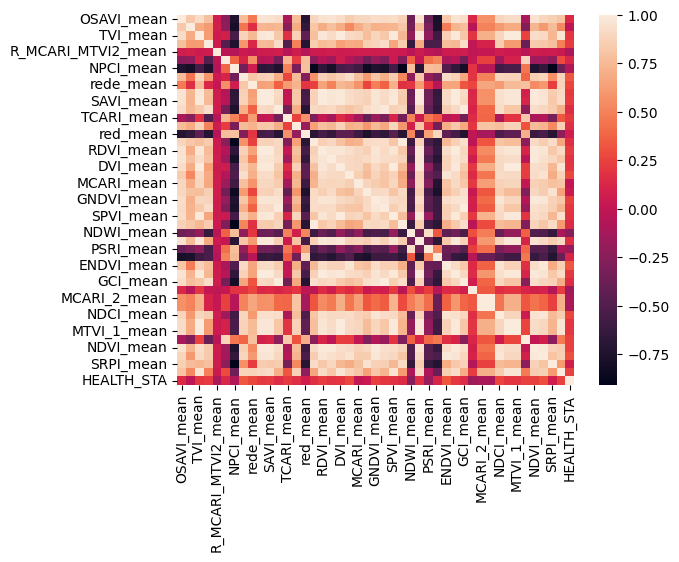

In [139]:

# Cleaning and normalizing the training and the target dataframe (i.e., df and df_target)
# so that AVERAGE, HEALTHY, and UNHEALTHY labels become [0, ]
df, df_target = dataset_load()
# Remove unnamed columns:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = clean_dataframe(df, 'HEALTH_STA')
#df = remove_outliers_iqr(df, 'HEALTH_STA')
df = df[df['HEALTH_STA'].notna()]
# DROP COLUMNS WITH ALL ROWS AS NAN OR EMPTY:
df = df.dropna(axis=1, how='all')
# Select only HEALTH_STA == 'HEALTHY' or HEALTH_STA == 'UNHEALTHY':
df = df[df['HEALTH_STA'] != 'AVARAGE']


le = preprocessing.LabelEncoder()
le.fit(df['HEALTH_STA'])
print('DF TRAINING HEALTH CLASSES:', list(le.classes_))
df['HEALTH_STA'] = le.transform(df['HEALTH_STA'])

## Feature & Target Selection for the training dataframe (df)
X = df[[col for col in df.columns]]
X = X.drop(df.columns[0], axis=1) # Droping the first dataframe's column (with IDs)
X = X.drop(['HEALTH_STA', 'DATT_mean', 'MTCI_mean', 'R_TCARI_OSAVI_mean'], axis=1) # Droping the label column from the dataframe
y = df['HEALTH_STA']
labels = np.unique(y)
print('Labels:', labels)
class_counts = y.value_counts()
print('Class counts for training', class_counts)
print('Where 0 is HEALTHY and 1 is UNHEALTHY')

features = X.columns

# Removing inf values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
mean_values = X.mean(axis=0)
X.fillna(mean_values, inplace=True)

# Putting the pixels and vegetation indices values into a scale from 0 to 1
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(X[features])
X = pd.DataFrame(x_scaled)
X.columns = features
X[features] = X[features].astype(float)

# Split the train and test sets into train and test sets, with the same proportion of classes
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

#############################################################################################################
##########################################VALIDATION DATASET \/##############################################
#############################################################################################################
# loading the dataframe for the next date
#df_target = remove_outliers_iqr(df_target, 'HEALTH_STA')
df_target = clean_dataframe(df_target, 'HEALTH_STA')
df_target = df_target[df_target['HEALTH_STA'].notna()]
# Select only HEALTH_STA == 'HEALTHY' or HEALTH_STA == 'UNHEALTHY':
df_target = df_target[df_target['HEALTH_STA'] != 'AVARAGE']

le = preprocessing.LabelEncoder()
le.fit(df_target['HEALTH_STA'])
print('DF TARGET HEALTH CLASSES:', list(le.classes_))
df_target['HEALTH_STA'] = le.transform(df_target['HEALTH_STA'])
y_target = df_target['HEALTH_STA']
labels = np.unique(y_target)
print('Labels:', labels)
class_counts = y_target.value_counts()
print('Class counts for validating', class_counts)
print('Where 0 is HEALTHY and 1 is UNHEALTHY')

X_next_date = df_target[[col for col in df_target.columns]]
X_next_date = X_next_date.drop(X_next_date.columns[0], axis=1) # Droping the first dataframe's column (with IDs)
X_next_date = X_next_date.drop(['HEALTH_STA'], axis=1)
y_next_date = df_target['HEALTH_STA']
X_next_date.replace([np.inf, -np.inf], np.nan, inplace=True)
next_date_mean_values = X_next_date.mean(axis=0)
X_next_date.fillna(next_date_mean_values, inplace=True)

min_max_scaler = preprocessing.MinMaxScaler()
x_next_date_scaled = min_max_scaler.fit_transform(X_next_date[features])
X_next_date = pd.DataFrame(x_next_date_scaled)
X_next_date.columns = features
X_next_date[features] = X_next_date[features].astype(float)

# Split the train and test sets into train and test sets
# The line below is not good because the test dataset is with unbalanced classes:
X_next_date_train, X_next_date_test, y_next_date_train, y_next_date_test = train_test_split(X_next_date, y_next_date, stratify=y_next_date, test_size=0.9, random_state=42)

class_counts = np.bincount(y_next_date_test)
print('Splitted unbalanced dataset for testing with the last date:')
print('class counts', class_counts)

# build, train, & predict model
model = SVC(kernel='rbf', C=0.00001, gamma='auto', probability=True, decision_function_shape='ovr', break_ties=True, random_state=42)
model.fit(X_train, y_train)
y_pred_svc = model.predict(X_next_date_test)

# evaluate results
print('##### SVC Metrics:')
print('MAE:', mean_absolute_error(y_next_date_test, y_pred_svc))
print('MSE:', mean_squared_error(y_next_date_test, y_pred_svc))
print('R2 Score:', r2_score(y_next_date_test, y_pred_svc))
print('F1-SCORE: ', f1_score(y_next_date_test, y_pred_svc, average='micro'))
print('TEST ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred_svc))

# Calculate accuracy per label
class_names = ['HEALTHY', 'UNHEALTHY']
label_accuracy = precision_recall_fscore_support(y_next_date_test, y_pred_svc, average=None, labels=[0, 1])
# The 'average=None' argument returns precision, recall, and F1-score for each label separately
print(label_accuracy)
# Print the accuracy per label
for label, accuracy in zip(labels, label_accuracy[0]):
    print(f"Label {label}: Test Accuracy = {accuracy}")

# Concatenating X and y to check the correlation values

combined_df = pd.concat([X, y], axis=1)
correlation_matrix = combined_df.corr()

import seaborn as sns
sns.heatmap(correlation_matrix)


# RANDOM FOREST MODEL:

In [140]:

# import numpy as np

# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestClassifier
# rf = RandomForestClassifier()
# param_grid = { 
#     'n_estimators': [100, 200, 500],
#     'max_features': [5, 'sqrt', 'log2'],
#     'max_depth' : [4,5,6,7,8],
#     'criterion' :['entropy', 'gini']
# }

# from scipy.stats import uniform

# print('##### Random Forest Classifier')
# # rfc = RandomForestClassifier(random_state=42)
# # CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=10)

# # # fit
# # CV_rfc.fit(X_train, y_train)
# # print('Best Params Grid Search:')
# # print(CV_rfc.best_params_)

# # Instantiate RandomizedSearchCV model
# rs_model = RandomizedSearchCV(RandomForestClassifier(n_jobs=-1, random_state=42),
#                                param_distributions=param_grid,
#                                n_iter=10,
#                                cv=10,
#                                verbose=True)
# rs_model.fit(X_train, y_train)
# print('Best Params RandomizedSearch (RF):')
# print(rs_model.best_params_)
# best_params = rs_model.best_params_

# print('Metrics (RFO)')
# rfc_best = RandomForestClassifier(**best_params)
# rfc_best.fit(X_train, y_train)
# y_pred_rfc = rfc_best.predict(X_next_date_test)

# print('MAE:', mean_absolute_error(y_next_date_test, y_pred_rfc))
# print('MSE:', mean_squared_error(y_next_date_test, y_pred_rfc))
# print('R2 Score:', r2_score(y_next_date_test, y_pred_rfc))
# print('F1-SCORE: ', f1_score(y_next_date_test, y_pred_rfc, average='micro'))
# print('TEST ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred_rfc))

# # Calculate accuracy per label
# label_accuracy = precision_recall_fscore_support(y_next_date_test, y_pred_rfc, average=None)
# # The 'average=None' argument returns precision, recall, and F1-score for each label separately
# # Print the accuracy per label
# for label, precision, recall, f1 in zip(labels, label_accuracy[0], label_accuracy[1], label_accuracy[2]):
#     print(f"Label {label}: Test Precision = {precision} | Recall = {recall} | F1-Score = {f1}")



# Performing a CNN classification task:

In [154]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from keras.models import Sequential
from keras.layers import Dense, Dropout
from tensorflow import keras
from scikeras.wrappers import KerasClassifier

# # Build the CNN model
def create_cnn_model(hidden_layer_dim):
    cnn_model = Sequential()
    cnn_model.add(Dense(32, activation='relu', input_shape=(hidden_layer_dim,)))
    cnn_model.add(Dense(64, activation='relu'))
    cnn_model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    # cnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return cnn_model

cnn_model = KerasClassifier(create_cnn_model, loss="binary_crossentropy", hidden_layer_dim=X_train.shape[1])

# Train the model
cnn_model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

y_pred_cnn = cnn_model.predict(X_next_date_test)
print(y_pred_cnn)
# evaluate results
print('##### CNN Metrics:')
print('MAE:', mean_absolute_error(y_next_date_test, y_pred_cnn))
print('MSE:', mean_squared_error(y_next_date_test, y_pred_cnn))
print('R2 Score:', r2_score(y_next_date_test, y_pred_cnn))
print('F1-SCORE: ', f1_score(y_next_date_test, y_pred_cnn, average='weighted'))
print('TEST ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred_cnn))

# Calculate accuracy per label
label_accuracy = precision_recall_fscore_support(y_next_date_test, y_pred_cnn, average=None)
# The 'average=None' argument returns precision, recall, and F1-score for each label separately
print(label_accuracy)
# Print the accuracy per label
for label, accuracy, recall, f1 in zip(labels, label_accuracy[0], label_accuracy[1], label_accuracy[2]):
    print(f"Label {label}: Test Accuracy = {accuracy}, Recall = {recall}, F1-Score = {f1}")

5/5 [==============================] - 0s 452us/step
[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
##### CNN Metrics:
MAE: 0.3082191780821918
MSE: 0.3082191780821918
R2 Score: -0.36875000000000013
F1-SCORE:  0.6192702424456297
TEST ACCURACY SCORE: 0.6917808219178082
(array([0.68888889, 0.72727273]), array([0.96875, 0.16   ]), array([0.80519481, 0.26229508]), array([96, 50]))
Label 0: Test Accuracy = 0.6888888888888889, Recall = 0.96875, F1-Score = 0.8051948051948051
Label 1: Test Accuracy = 0.7272727272727273, Recall = 0.16, F1-Score = 0.2622950819672131


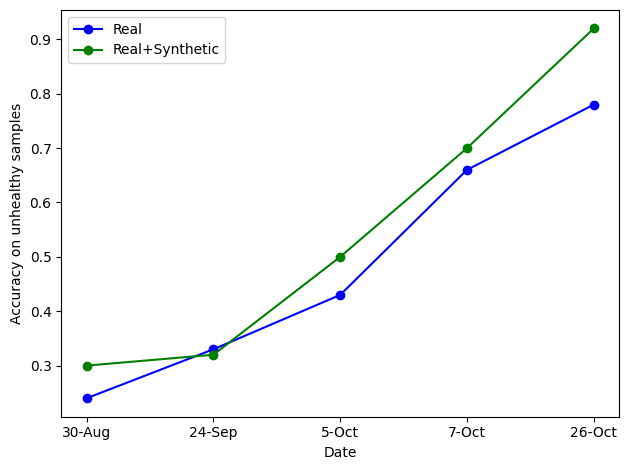

In [162]:
import matplotlib.pyplot as plt
import numpy as np

dates = ['30-Aug', '24-Sep', '5-Oct', '7-Oct', '26-Oct']
accuracy_real = [0.24, 0.33, 0.43, 0.66, 0.78]
accuracy_real_synthetic = [0.3, 0.32, 0.5, 0.7, 0.92]

fig, ax = plt.subplots()
ax.plot(dates, accuracy_real, marker='o', linestyle='-', label='Real', color='blue')
ax.plot(dates, accuracy_real_synthetic, marker='o', linestyle='-', label='Real+Synthetic', color='green')

ax.set_xlabel('Date')
ax.set_ylabel('Accuracy')
ax.legend()

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Performing a XGBoost classification

In [142]:
from xgboost import XGBClassifier

# declare parameters
params = {
            'objective':'binary:logistic',
            'max_depth': 4,
            'alpha': 10,
            'learning_rate': 0.01,
            'n_estimators':500
        } 
            
            
# instantiate the classifier 
xgb_clf = XGBClassifier(**params)
xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_next_date_test)

# evaluate results
print('##### XGBoost Metrics:')
print('MAE:', mean_absolute_error(y_next_date_test, y_pred_xgb))
print('MSE:', mean_squared_error(y_next_date_test, y_pred_xgb))
print('R2 Score:', r2_score(y_next_date_test, y_pred_xgb))
print('F1-SCORE: ', f1_score(y_next_date_test, y_pred_xgb, average='weighted'))
print('TEST ACCURACY SCORE:', accuracy_score(y_next_date_test, y_pred_xgb))

# Calculate accuracy per label
label_accuracy = precision_recall_fscore_support(y_next_date_test, y_pred_xgb, average=None)
# The 'average=None' argument returns precision, recall, and F1-score for each label separately
print(label_accuracy)
# Print the accuracy per label
for label, accuracy, recall, f1 in zip(labels, label_accuracy[0], label_accuracy[1], label_accuracy[2]):
    print(f"Label {label}: Test Accuracy = {accuracy}, Recall = {recall}, F1-Score = {f1}")

##### XGBoost Metrics:
MAE: 0.21232876712328766
MSE: 0.21232876712328766
R2 Score: 0.057083333333333264
F1-SCORE:  0.7766294129325345
TEST ACCURACY SCORE: 0.7876712328767124
(array([0.79279279, 0.77142857]), array([0.91666667, 0.54      ]), array([0.85024155, 0.63529412]), array([96, 50]))
Label 0: Test Accuracy = 0.7927927927927928, Recall = 0.9166666666666666, F1-Score = 0.8502415458937198
Label 1: Test Accuracy = 0.7714285714285715, Recall = 0.54, F1-Score = 0.6352941176470589


In [143]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Define the number of folds (k)
k = 10

# Create an instance of the k-fold cross-validator
kfold = KFold(n_splits=k, shuffle=True, random_state=42)

# Perform k-fold cross-validation
scores = cross_val_score(model, X_next_date_test, y_next_date_test, cv=kfold)
rfc_scores = cross_val_score(rfc_best, X_next_date_test, y_next_date_test, cv=kfold)
cnn_scores = cross_val_score(cnn_model, X_next_date_test, y_next_date_test, cv=kfold)
xgb_scores = cross_val_score(xgb_clf, X_next_date_test, y_next_date_test, cv=kfold)

# Print the cross-validation scores
print('\n SVC:')
print("Cross-validation scores:", scores)
print("Average score:", scores.mean())

print('\n RFC:')
print("Cross-validation scores:", rfc_scores)
print("Average score:", rfc_scores.mean())

print('\n CNN:')
print("Cross-validation scores:", cnn_scores)
print("Average score:", cnn_scores.mean())

print('\n XGB:')
print("Cross-validation scores:", xgb_scores)
print("Average score:", xgb_scores.mean())

NameError: name 'rfc_best' is not defined

In [ ]:
# Plot the confusion matrix for the SVM model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['Healthy', 'Unhealthy']
f, axes = plt.subplots(1, 3, figsize=(20, 5), sharey='row')

cm = confusion_matrix(y_next_date_test, y_pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], xticks_rotation=45)
disp.ax_.set_title("Support Vector Classifier")
disp.im_.colorbar.remove()
disp.ax_.set_xlabel('')


# Plot the confusion matrix for the Random Forest model
cm = confusion_matrix(y_next_date_test, y_pred_rfc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[1], xticks_rotation=45)
disp.ax_.set_title("Random Forest")
disp.im_.colorbar.remove()
disp.ax_.set_xlabel('')
disp.ax_.set_ylabel('')

cm = confusion_matrix(y_next_date_test, y_pred_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[2], xticks_rotation=45)
disp.ax_.set_title("CNN")
disp.im_.colorbar.remove()
disp.ax_.set_xlabel('')
disp.ax_.set_ylabel('')

f.text(0.4, -0.05, 'Predicted label', ha='left')
plt.subplots_adjust(wspace=0.20, hspace=0.1)

f.colorbar(disp.im_, ax=axes)
plt.show()

In [ ]:
import shap
import sklearn
import numpy 
#explainer = shap.KernelExplainer(model.predict_proba, X_train, link="logit")
#shap_values = explainer.shap_values(X_next_date_test, nsamples=100)
#print(explainer.expected_value)
#print(shap_values)

#df_shap = pd.DataFrame((zip(X.columns[np.argsort(np.abs(shap_values).mean(0))][::-1], -np.sort(-np.abs(shap_values).mean(0)))), columns=["feature", "importance"])
#explainer = shap.Explainer(xgb_clf)
#print(explainer(X_train))

#shap_values = explainer(X_train)
#shap.plots.beeswarm(explainer)

#shap.force_plot(explainer.expected_value[0], shap_values[0][0,:], X_test.iloc[0,:], matplotlib=True)



In [ ]:
import shap
import time

def print_accuracy(f):
    print("Accuracy = {0}%".format(100*np.sum(f(X_next_date_test) == y_next_date_test)/len(y_next_date_test)))
    time.sleep(0.5) # to let the print get out before any progress bars


#svc_linear = sklearn.svm.SVC(kernel='rbf', probability=True)
#svc_linear.fit(X_train, y_train)
#print_accuracy(svc_linear.predict)

# explain all the predictions in the test set
#explainer = shap.KernelExplainer(svc_linear.predict_proba, X_train)
#shap_values = explainer.shap_values(X_test)
#shap.plots.bar(explainer(X_test), max_display=10) # default is max_display=12


In [ ]:
from collections import Counter


print('Test', Counter(y_test))

In [ ]:
force_plot = shap.force_plot(explainer.expected_value[0], shap_values[0], X_test)
from IPython.display import HTML
HTML(f"<div style='background-color:Lavender;'>{shap.getjs() + force_plot.html()}</div>")

In [ ]:
!python -m pip install numpy==1.23.5

In [ ]:
import xgboost
import shap
import numpy 

# select backgroud for shap
background = X_train.values[np.random.choice(X_train.shape[0], 100, replace=False)]
# DeepExplainer to explain predictions of the model
# explainer = shap.DeepExplainer(model, background)

xgb_model = xgboost.XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

# The SHAP Values
explainer_rfc = shap.Explainer(rfc_best)
explainer_xgb = shap.Explainer(xgb_model)
explainer_cnn = shap.DeepExplainer(cnn_model_2.predict, X_train.values)

shap_values_rfc = explainer_rfc(X_test)
shap_values_xgb = explainer_xgb(X_test)

# Calculate the mean SHAP values
mean_shap_rfc = np.mean(np.abs(shap_values_rfc.values), axis=0).flatten()
mean_shap_xgb = np.mean(np.abs(shap_values_xgb.values), axis=0).flatten()

# Normalize the mean SHAP values for Random Forest
mean_shap_rfc_norm = (mean_shap_rfc - np.min(mean_shap_rfc)) / (np.max(mean_shap_rfc) - np.min(mean_shap_rfc))

# Normalize the mean SHAP values for XGBoost
mean_shap_xgb_norm = (mean_shap_xgb - np.min(mean_shap_xgb)) / (np.max(mean_shap_xgb) - np.min(mean_shap_xgb))


# Print the shape of mean_shap_rfc
print("Shape of mean_shap_rfc:", mean_shap_rfc.shape)

# Reshape the mean SHAP values to have the same shape
# mean_shap_rfc = np.reshape(mean_shap_rfc, (3, 44))
# mean_shap_xgb = np.reshape(mean_shap_xgb, (1, 44))

# Compute the average SHAP values
# mean_shap_avg = np.concatenate([mean_shap_rfc, mean_shap_xgb], axis=0)

#shap_values_cnn = explainer_cnn.shap_values(X_test.values)
print(shap_values_rfc.shape)
print(shap_values_xgb.shape)


# Create a figure and axis for the plot
fig, ax = plt.subplots(figsize=(10, 15))

# Set the bar height and offset
bar_height = 0.75
bar_offset = np.arange(len(features)) * 2

# Reshape the mean SHAP values arrays to have the same shape
mean_shap_rfc_norm = np.reshape(mean_shap_rfc_norm, (-1, 1))
mean_shap_xgb_norm = np.reshape(mean_shap_xgb_norm, (-1, 1))

# Calculate the mean of the normalized SHAP values
mean_shap_avg_norm = np.mean([mean_shap_rfc_norm[:len(features)], mean_shap_xgb_norm], axis=0)
mean_shap_scalar = np.mean(mean_shap_avg_norm)

bar_offset = bar_offset[::-1]
features = features[::-1]

# Plot the mean SHAP values for Random Forest
ax.barh(bar_offset, mean_shap_rfc_norm.flatten()[:len(features)], bar_height, label='Random Forest', alpha=0.7)

# Plot the mean SHAP values for XGBoost
ax.barh(bar_offset + bar_height, mean_shap_xgb_norm.flatten()[:len(features)], bar_height, label='XGBoost', alpha=0.7)

# Add a line representing the mean of the SHAP values
ax.axvline(mean_shap_scalar, color='black', linestyle='--', label='Mean SHAP', linewidth=1)

# Set plot properties
ax.set_title("Comparison of Feature Importance")
ax.set_xlabel("Normalized Mean SHAP Value")
ax.set_ylabel("Features")
ax.set_yticks(bar_offset + bar_height / 2)
ax.set_yticklabels([label.replace('_mean', '') for label in features])

ax.invert_yaxis()

ax.legend()
ax.set_ylim(bar_offset[0] - bar_height, bar_offset[-1] + bar_height * 1.5)

# Show the plot
plt.tight_layout()
plt.show()
# SHAP Charts
# shap.plots.bar(shap_values_xgb, max_display=10) # default is max_display=12
# shap.plots.heatmap(shap_values_xgb[1:100])

# The SHAP Values

# shap_values_rfc = explainer(X_test)

# SHAP Charts
#shap.plots.bar(shap_values_rfc, max_display=10) # default is max_display=12
#shap.plots.heatmap(shap_values_rfc[1:100])

# The SHAP Values

#shap_values_cnn = explainer(X_test)

# SHAP Charts
#shap.plots.bar(shap_values_cnn, max_display=10) # default is max_display=12
#shap.plots.heatmap(shap_values_cnn[1:100])


In [ ]:
# Create the figure and axis
fig = plt.figure(figsize=(50, 50))
ax = fig.add_subplot(141, projection='3d')
# Define the positions for the bars
r1 = np.arange(47)
r2 = r1 + 0.25
r3 = r1 + 0.5

# Create the 3D bars for each model
ax.bar3d(r1, np.zeros_like(r1), np.zeros_like(r1), 0.6, 0.6, perm_importance_svc.importances_mean, color='#acc2d9', alpha=0.6)
ax.bar3d(r2, np.ones_like(r2), np.zeros_like(r2), 0.6, 0.6, perm_importance_rfc.importances_mean, color='#a8ff04', alpha=0.6)
ax.bar3d(r3, 2*np.ones_like(r3), np.zeros_like(r3), 0.6, 0.6, perm_importance_cnn.importances_mean, color='#70b23f', alpha=0.6)

# Set the tick labels and limits
ax.set_yticks(np.arange(3))
ax.set_xticks(np.arange(len(features)))
ax.set_xticklabels(features)
ax.tick_params(axis='both', which='major', labelsize=10)
models = ['SVC', 'Random Forest', 'CNN']
ax.set_yticklabels(models)
ax.set_ylim(0, 2.5)
ax.set_zlim(-0.050, 0.1)  # Adjust the z-axis limits as needed
plt.gcf().autofmt_xdate()
# Set labels and title
ax.set_xlabel('Features', labelpad=50)
ax.set_ylabel('Model')
ax.set_zlabel('Permutation Importance')
ax.set_title('Permutation Importance for Three Models and 47 Features')
# Adjust the view angle
ax.view_init(elev=30, azim=-45)

plt.xticks(rotation=30)
plt.tight_layout()
# Show the plot
plt.show()

In [ ]:
# Extract the dates column and remove duplicates
dates = df['date'].unique()
print(dates)
# Set the dates column as the index
df.set_index('date', inplace=True)
